# Repeat Customers Churn Modeling

This notebook trains and segments churn risk for repeat customers only, using the exported file from the EDA split notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

In [2]:
repeat_path = Path('output/repeat_customers.csv')
if not repeat_path.exists():
    raise FileNotFoundError('Missing output/repeat_customers.csv. Run eda_and_customer_split.ipynb first.')

repeat_data = pd.read_csv(repeat_path)
print(f'Repeat customer rows: {len(repeat_data):,}')
print(f'Churn rate: {repeat_data["churned"].mean()*100:.1f}%')

Repeat customer rows: 5,490
Churn rate: 60.3%


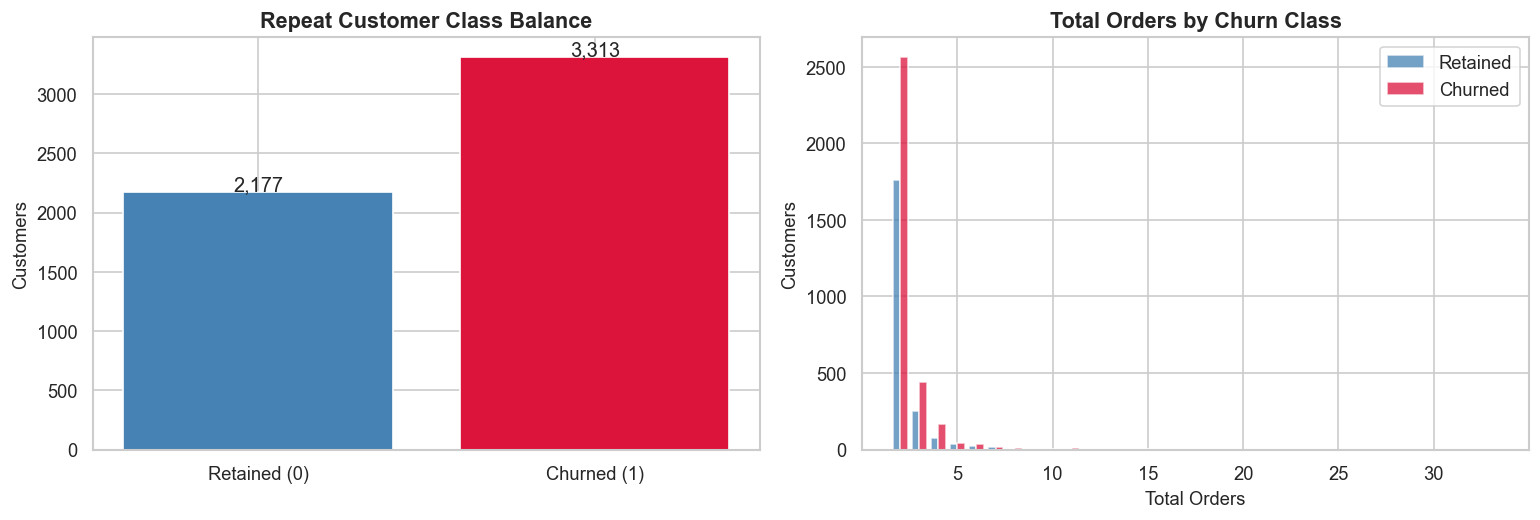

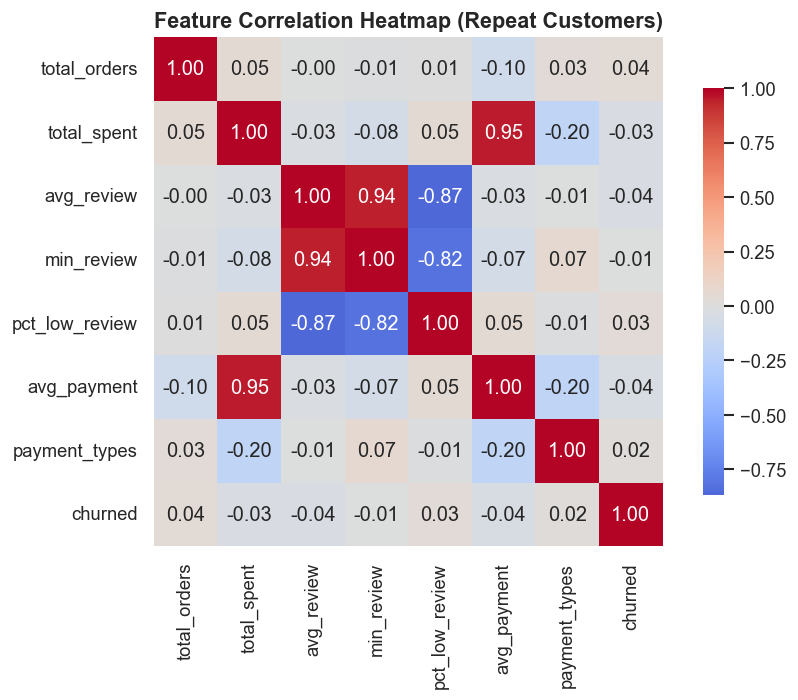

In [7]:
# Additional EDA visualizations for repeat customers
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Churn class balance within repeat customers
class_counts = repeat_data['churned'].value_counts().sort_index()
axes[0].bar(['Retained (0)', 'Churned (1)'], class_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Repeat Customer Class Balance', fontweight='bold')
axes[0].set_ylabel('Customers')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 15, f'{v:,}', ha='center')

# Total orders distribution by churn class
bins = np.arange(2, repeat_data['total_orders'].max() + 2) - 0.5
axes[1].hist(
    [repeat_data.loc[repeat_data['churned'] == 0, 'total_orders'],
     repeat_data.loc[repeat_data['churned'] == 1, 'total_orders']],
    bins=bins,
    label=['Retained', 'Churned'],
    color=['steelblue', 'crimson'],
    alpha=0.75,
    stacked=False
)
axes[1].set_title('Total Orders by Churn Class', fontweight='bold')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('Customers')
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlation heatmap of modeling features
eda_features = ['total_orders', 'total_spent', 'avg_review', 'min_review', 'pct_low_review', 'avg_payment', 'payment_types']
plt.figure(figsize=(8, 6))
corr = repeat_data[eda_features + ['churned']].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap (Repeat Customers)', fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
FEATURES = ['total_orders', 'total_spent', 'avg_review', 'min_review', 'pct_low_review', 'avg_payment', 'payment_types']
X = repeat_data[FEATURES]
y = repeat_data['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

              precision    recall  f1-score   support

    Retained       0.42      0.41      0.41       544
     Churned       0.62      0.63      0.63       829

    accuracy                           0.54      1373
   macro avg       0.52      0.52      0.52      1373
weighted avg       0.54      0.54      0.54      1373

ROC-AUC: 0.5181


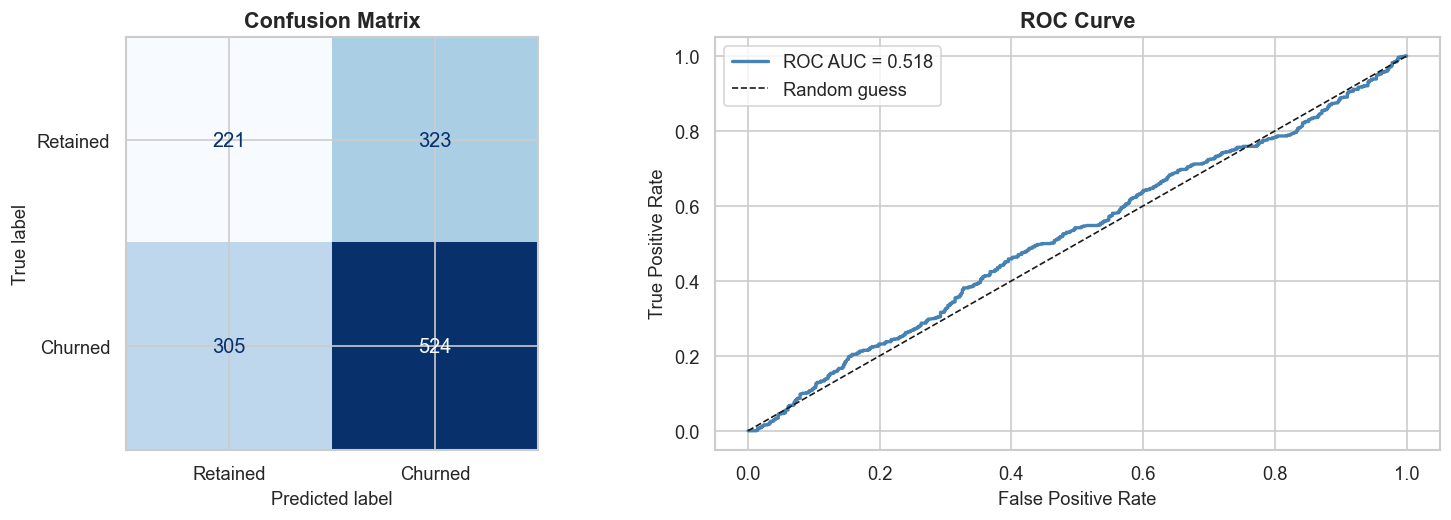

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

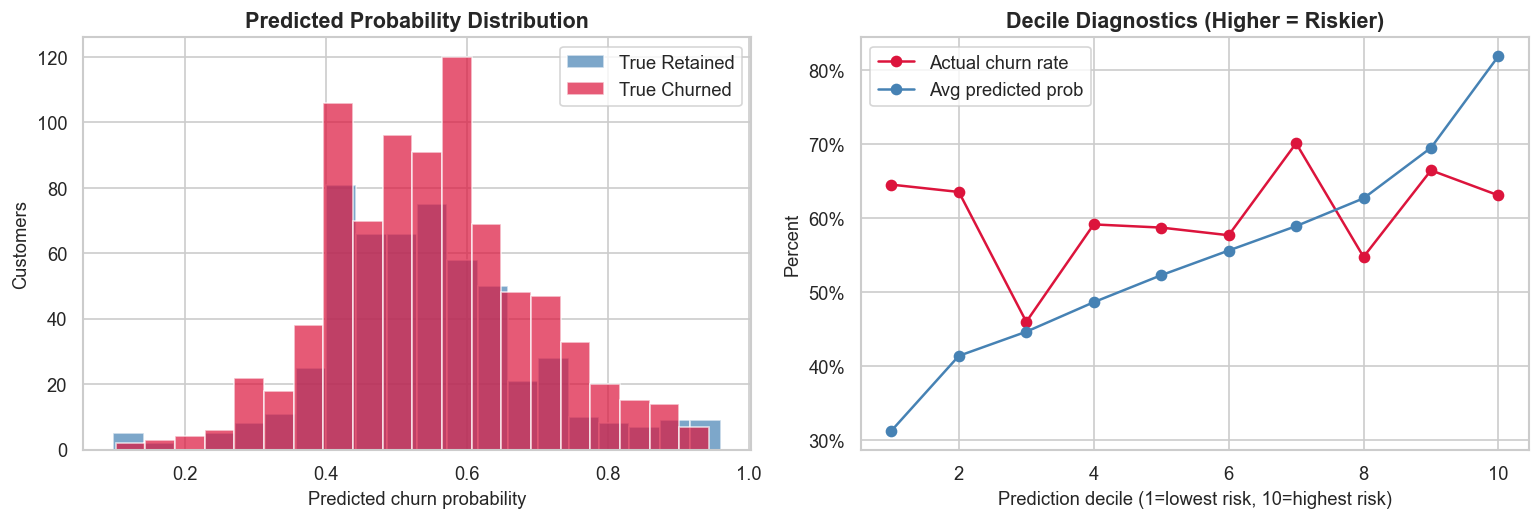

Decile diagnostic table:
 prob_decile  customers  actual_churn_rate  avg_pred_prob
           1        138           0.644928       0.312785
           2        137           0.635036       0.413858
           3        137           0.459854       0.446458
           4        137           0.591241       0.486260
           5        138           0.586957       0.522671
           6        137           0.576642       0.555979
           7        137           0.700730       0.588940
           8        137           0.547445       0.626456
           9        137           0.664234       0.694667
          10        138           0.630435       0.818388


In [8]:
# Predicted probability diagnostics
diagnostics = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': y_prob
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Probability distribution by true class
axes[0].hist(diagnostics.loc[diagnostics['y_true'] == 0, 'y_prob'], bins=20, alpha=0.7, color='steelblue', label='True Retained')
axes[0].hist(diagnostics.loc[diagnostics['y_true'] == 1, 'y_prob'], bins=20, alpha=0.7, color='crimson', label='True Churned')
axes[0].set_title('Predicted Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted churn probability')
axes[0].set_ylabel('Customers')
axes[0].legend()

# Decile lift-style view
diagnostics['prob_decile'] = pd.qcut(diagnostics['y_prob'], 10, labels=False, duplicates='drop') + 1
decile_stats = diagnostics.groupby('prob_decile').agg(
    customers=('y_true', 'count'),
    actual_churn_rate=('y_true', 'mean'),
    avg_pred_prob=('y_prob', 'mean')
).reset_index()

axes[1].plot(decile_stats['prob_decile'], decile_stats['actual_churn_rate'] * 100, marker='o', color='crimson', label='Actual churn rate')
axes[1].plot(decile_stats['prob_decile'], decile_stats['avg_pred_prob'] * 100, marker='o', color='steelblue', label='Avg predicted prob')
axes[1].set_title('Decile Diagnostics (Higher = Riskier)', fontweight='bold')
axes[1].set_xlabel('Prediction decile (1=lowest risk, 10=highest risk)')
axes[1].set_ylabel('Percent')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()

plt.tight_layout()
plt.show()

print('Decile diagnostic table:')
print(decile_stats.to_string(index=False))

In [5]:
# Score all repeat customers and segment
repeat_data['churn_probability'] = model.predict_proba(X)[:, 1]

scaler = StandardScaler()
score_scaled = scaler.fit_transform(repeat_data[['churn_probability']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
repeat_data['risk_cluster'] = kmeans.fit_predict(score_scaled)

centroids = pd.Series(kmeans.cluster_centers_.flatten())
cluster_rank = centroids.sort_values().index.tolist()
cluster_to_label = {
    cluster_rank[0]: 'Low Risk',
    cluster_rank[1]: 'Medium Risk',
    cluster_rank[2]: 'High Risk'
}
repeat_data['risk_segment'] = repeat_data['risk_cluster'].map(cluster_to_label)

seg_summary = repeat_data.groupby('risk_segment').agg(
    customers=('customer_unique_id', 'count'),
    actual_churn_pct=('churned', 'mean'),
    avg_prob=('churn_probability', 'mean')
).round(3)

display_summary = seg_summary.copy()
display_summary['actual_churn_pct'] = (display_summary['actual_churn_pct'] * 100).round(1).astype(str) + '%'
display_summary['avg_prob'] = (display_summary['avg_prob'] * 100).round(1).astype(str) + '%'
print(display_summary.to_string())

              customers actual_churn_pct avg_prob
risk_segment                                     
High Risk          1074            92.4%    78.1%
Low Risk           1827            31.3%    39.1%
Medium Risk        2589            67.6%    56.8%


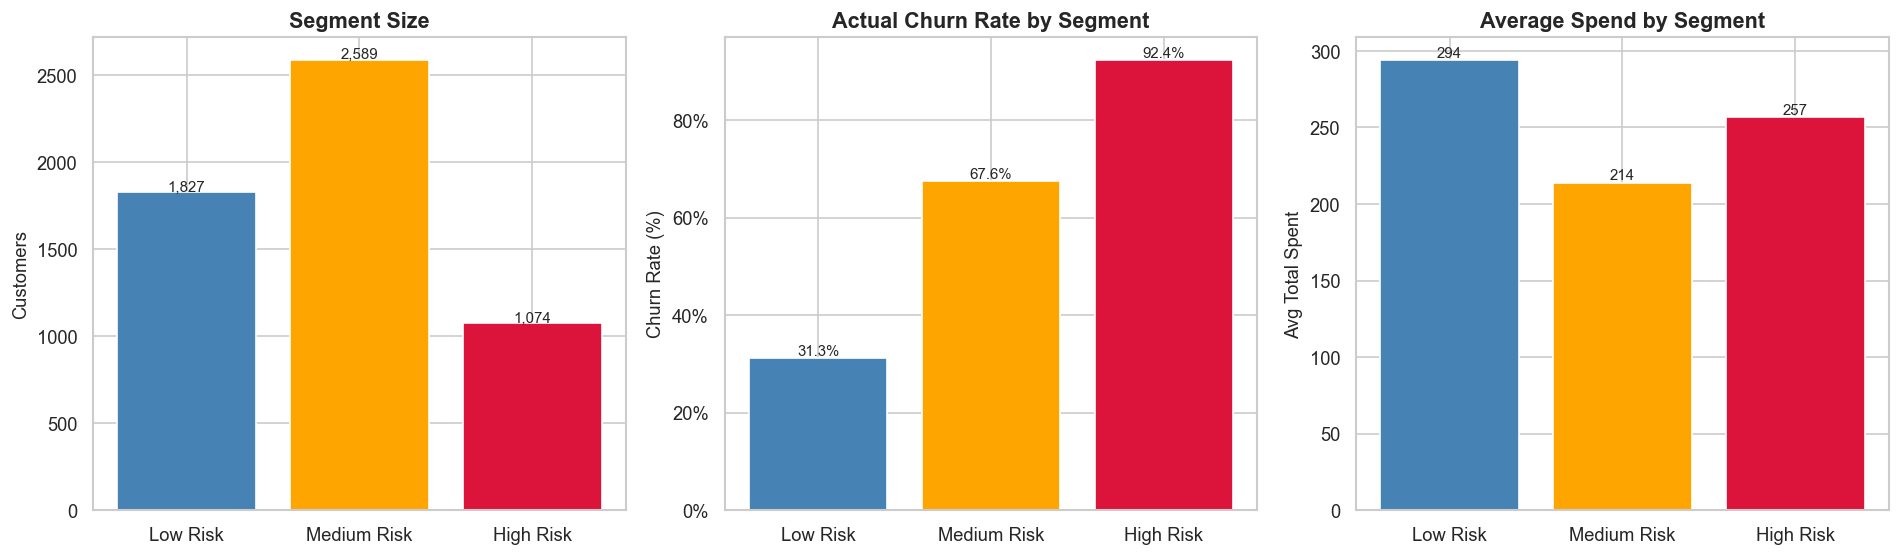

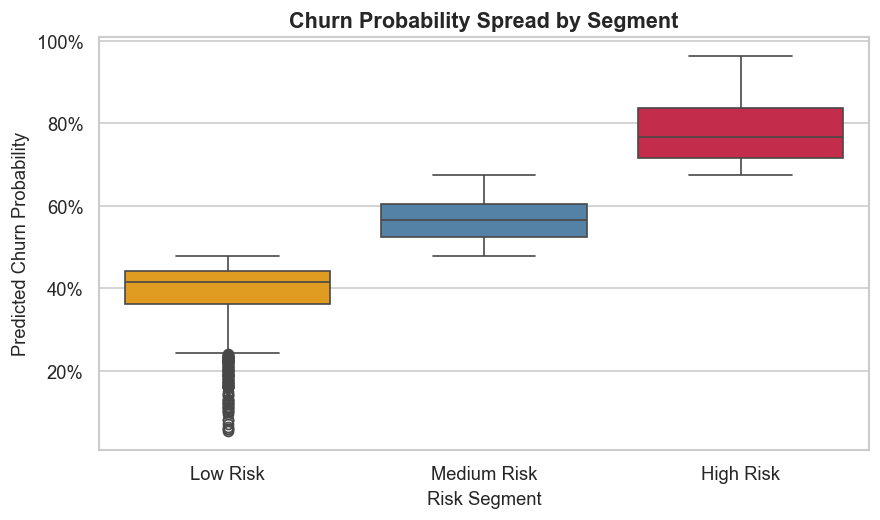

In [10]:
# Segment profile visualizations
order = ['Low Risk', 'Medium Risk', 'High Risk']
profile = repeat_data.groupby('risk_segment').agg(
    customers=('customer_unique_id', 'count'),
    actual_churn=('churned', 'mean'),
    avg_prob=('churn_probability', 'mean'),
    avg_spent=('total_spent', 'mean'),
    avg_review=('avg_review', 'mean')
).reindex(order)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].bar(order, profile['customers'], color=['steelblue', 'orange', 'crimson'])
axes[0].set_title('Segment Size', fontweight='bold')
axes[0].set_ylabel('Customers')
for i, v in enumerate(profile['customers'].fillna(0)):
    axes[0].text(i, v + 10, f'{int(v):,}', ha='center', fontsize=9)

axes[1].bar(order, profile['actual_churn'] * 100, color=['steelblue', 'orange', 'crimson'])
axes[1].set_title('Actual Churn Rate by Segment', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate((profile['actual_churn'] * 100).fillna(0)):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

axes[2].bar(order, profile['avg_spent'], color=['steelblue', 'orange', 'crimson'])
axes[2].set_title('Average Spend by Segment', fontweight='bold')
axes[2].set_ylabel('Avg Total Spent')
for i, v in enumerate(profile['avg_spent'].fillna(0)):
    axes[2].text(i, v + 2, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7.5, 4.5))
sns.boxplot(
    data=repeat_data,
    x='risk_segment',
    y='churn_probability',
    hue='risk_segment',
    order=order,
    palette=['steelblue', 'orange', 'crimson'],
    dodge=False,
    legend=False
)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.title('Churn Probability Spread by Segment', fontweight='bold')
plt.xlabel('Risk Segment')
plt.ylabel('Predicted Churn Probability')
plt.tight_layout()
plt.show()

In [6]:
repeat_data.drop(columns=['risk_cluster'], inplace=True)
repeat_output_path = Path('output/repeat_customer_segments.csv')
repeat_data.to_csv(repeat_output_path, index=False)
print(f'Exported segmented repeat customers -> {repeat_output_path}')

Exported segmented repeat customers -> output\repeat_customer_segments.csv
